In [1]:
import pandas as pd
import numpy as np
import pylab as pl
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import seaborn as sns

In [2]:
titanic_test_df=pd.read_csv("titanic_test.CSV")
titanic_test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
titanic_train_df=pd.read_csv("titanic_train.CSV")
titanic_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_survived_df=pd.read_csv("titanic_survied.CSV")
titanic_survived_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [5]:
titanic_train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
missing_values = titanic_train_df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
X_train = titanic_train_df[['Sex', 'Age']].values
X_train[0:5]
print(type(X_train))


<class 'numpy.ndarray'>


In [8]:
from sklearn import preprocessing
X_train[0,:] = X_train[0,:].astype(str)

Sex = preprocessing.LabelEncoder()

X_train[:,0] = Sex.fit_transform(X_train[:,0])

X_train[0:5]

array([[1, '22.0'],
       [0, 38.0],
       [0, 26.0],
       [0, 35.0],
       [1, 35.0]], dtype=object)

In [9]:
titanic_survived_df['Survived'] = titanic_survived_df['Survived'].astype('int')
titanic_survived_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [10]:
from sklearn import preprocessing
X_train = preprocessing.StandardScaler().fit(X_train).transform(X_train)
X_train[0:5]

array([[ 0.73769513, -0.53037664],
       [-1.35557354,  0.57183099],
       [-1.35557354, -0.25482473],
       [-1.35557354,  0.36516706],
       [ 0.73769513,  0.36516706]])

## جایگزین کردن سن های nan با میانگین

In [11]:
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
Y_train = np.asarray(titanic_train_df['Survived'])
Y_train [0:5]

array([0, 1, 1, 1, 0], dtype=int64)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,Y_train)
y_pred = LR.predict(X_train)

In [13]:
print(y_pred)
print(Y_train)

[0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0 0
 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0
 1 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 1 1 1
 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0
 0 1 0 1 1 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0
 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 1 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0
 0 0 1 0 0 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0
 0 0 1 0 1 1 0 0 0 0 0 0 

In [14]:
from sklearn.metrics import jaccard_score
jaccard_score(y_pred, Y_train,pos_label=0)

0.7112462006079028

## حذف سن های nan

In [15]:
df_titanic_cleaned = titanic_train_df.dropna(subset=['Age'])

# انتخاب ویژگی‌ها پس از حذف مقادیر NaN
X_train1 = df_titanic_cleaned[['Sex', 'Age']].values


In [16]:
Y_train1 = np.asarray(df_titanic_cleaned['Survived'])
Y_train1 [0:5]

array([0, 1, 1, 1, 0], dtype=int64)

In [17]:
X_train1[0,:] = X_train[0,:].astype(str)

Sex = preprocessing.LabelEncoder()

X_train1[:,0] = Sex.fit_transform(X_train1[:,0])

X_train1[0:5]

array([[0, '-0.5303766406838785'],
       [1, 38.0],
       [1, 26.0],
       [1, 35.0],
       [2, 35.0]], dtype=object)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR1 = LogisticRegression(C=0.01, solver='liblinear').fit(X_train1,Y_train1)
y_pred1 = LR.predict(X_train1)

In [19]:
print(y_pred1)
print(Y_train1)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [20]:
from sklearn.metrics import jaccard_score
jaccard_score(y_pred1, Y_train1,pos_label=0)

0.5938375350140056

## پیدا کردن رابطه ای برای سن

In [21]:
def age_group (Age):
    if Age <4:
        return 0 
    elif 4<=Age and Age<16:
        return 1
    elif 16<=Age and Age<22:
        return 2
    elif 22<=Age and Age<30:
        return 3
    elif 30<=Age and Age<45:
        return 4
    return 5

df_titanic_cleaned['Age_Cat'] = df_titanic_cleaned['Age'].apply(age_group)

C:\Users\Asus\AppData\Local\Temp\ipykernel_1992\1426724394.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titanic_cleaned['Age_Cat'] = df_titanic_cleaned['Age'].apply(age_group)


In [22]:
age_cats = {
    0: "baby",
    1: "children",
    2: "teen",
    3: "young adult",
    4: "adult",
    5: "elder"
}

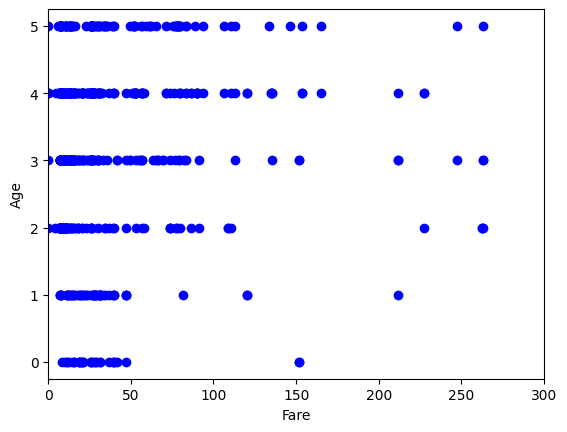

In [23]:
plt.scatter(df_titanic_cleaned.Fare,df_titanic_cleaned.Age_Cat , color="blue")
plt.xlim(0, 300)  # محدوده محور X (Fare)
plt.xlabel("Fare")
plt.ylabel("Age")
plt.show()

## test

In [24]:
missing_values = titanic_test_df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [25]:
df_titanic_test_cleaned = titanic_test_df.dropna(subset=['Sex'])

In [26]:
imputer_Age = SimpleImputer(strategy='mean')
df_titanic_test_cleaned['Age'] = imputer_Age.fit_transform(df_titanic_test_cleaned[['Age']])
df_titanic_test_cleaned['Sex'] = df_titanic_test_cleaned['Sex'].map({'male': 0, 'female': 1})
X_test = df_titanic_test_cleaned[['Sex', 'Age']].values


In [27]:
print(np.isnan(X_test).sum())  # باید 0 باشد
print(type(X_test))
print(X_test.shape)

0
<class 'numpy.ndarray'>
(418, 2)


In [28]:
Y_test = np.asarray(titanic_survived_df['Survived'])
Y_test [0:5]

array([0, 1, 0, 0, 1])

In [29]:
print(np.isnan(X_test).sum())  # باید 0 باشد
print(np.isnan(Y_test).sum())

0
0


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR_test = LogisticRegression(C=0.01, solver='liblinear').fit(X_test,Y_test)
yhat = LR_test.predict(X_test)
print(yhat[0:5])

[0 0 0 0 1]


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(Y_test, yhat, labels=[1,0]))

[[102  50]
 [  0 266]]


Confusion matrix, without normalization
[[102  50]
 [  0 266]]


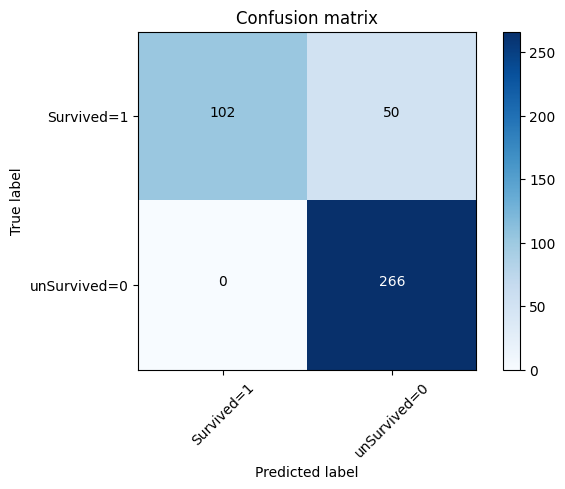

In [32]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(Y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Survived=1','unSurvived=0'],normalize= False,  title='Confusion matrix')

In [34]:
from sklearn.metrics import jaccard_score
jaccard_score(yhat, Y_test,pos_label=0)

0.8417721518987342